# Experiment 1C: Coincidence — Hidden-Layer Perturbation (Learnable Tau)

This notebook implements the coincidence-detection experiment with **hidden-layer perturbation**.

**Key idea:** Train a SLAYER SNN (Input → 3 hidden → 3 output) on coincidence data,
then at test time perturb the **output spikes of the hidden layer** to probe whether
the network maintains temporal (synchrony) representations internally.

- **Architecture:** 60 input → 3 hidden (SRMALPHA, learnable tau) → 3 output
- **Dataset:** Coincidence task with 3 classes (A, B, C), controlled by lambda (overlap)
- **Perturbation:** Fraction f of hidden spikes randomly relocated (preserving spike count)

## 1. Imports and Setup

In [1]:
import os
import sys
import json
import random
from typing import Optional

import numpy as np
from scipy import io as sio
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

import slayerSNN as snn

MS = 1e-3  # Millisecond constant

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 2. SLAYER and Training Parameters

In [2]:
# --- SLAYER neuron and simulation descriptors ---
# Coincidence dataset uses 4000 time steps (not 1000 like ISI)
SIM_PARAMS = {"Ts": 1, "tSample": 1000}
LIF_PARAMS = {
    "type": "SRMALPHA",
    "theta": 1,
    "tauSr": 1,
    "tauRho": 1,
    "tauRef": 1,
    "scaleRef": 2,
    "scaleRho": 1,
}

# --- Dataset constants ---
NUM_NEURONS = 60   # 3 groups of 20 neurons
NUM_CLASSES = 3    # Classes A, B, C
T = 1000           # Time steps

# --- Data split ratios ---
TRAIN_RATIO = 0.6
VAL_RATIO = 0.15
TEST_RATIO = 0.25

# --- Training hyper-parameters ---
HIDDEN_UNITS = 3   # Only 3 hidden neurons (coincidence detection)
EPOCHS = 501
BATCH_SIZE = 32
LEARNING_RATE = 0.001
PSP_FILTER_LR_SCALE = 10  # Higher LR for learnable tau
SEED = 42

# --- Hidden-perturbation sweep ---
F_VALUES = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
NUM_REPEATS = 3  # Repeated evaluations per f for error bars

# --- Lambda values to evaluate (disturbance/overlap levels) ---
LAMBDA_VALUES = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

## 3. Load Coincidence Dataset

In [3]:
def load_coin_data(data_file: str = "coin_dataset.mat"):
    """Load coincidence dataset from .mat file.

    Args:
        data_file: Path to the combined .mat file.

    Returns:
        Tuple of (X, Y, lambdas) numpy arrays.
    """
    data = sio.loadmat(data_file)
    X = data["X"]                    # (N, 60, 4000)
    Y = data["Y"].ravel()            # (N,)
    lambdas = data["lambda"].ravel()  # (N,)

    print(f"Loaded {data_file}: X={X.shape}, Y={Y.shape}")
    print(f"Lambda values: {np.unique(lambdas)}")
    print(f"Classes: {np.unique(Y)}, Time steps: {X.shape[2]}")
    return X, Y, lambdas


X_all, Y_all, lambda_all = load_coin_data("coin_dataset.mat")

Loaded coin_dataset.mat: X=(16500, 60, 4000), Y=(16500,)
Lambda values: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Classes: [0 1 2], Time steps: 4000


## 4. Hidden-Layer Spike Perturbation

These utilities randomly relocate a fraction *f* of each neuron's spikes,
preserving the total spike count per neuron. At f=0 the signal is untouched;
at f=1 all temporal structure is destroyed (pure rate signal).

In [4]:
def partial_randomize_spike_train(
    spike_train: np.ndarray,
    f: float = 0.0,
    max_attempts: int = 50,
) -> np.ndarray:
    """Randomly relocate a fraction *f* of each neuron's spikes.

    For every neuron, *f* of its spikes are removed from their original
    positions and placed at uniformly random empty time bins.  The total
    spike count per neuron is preserved.

    Args:
        spike_train: Binary array of shape (num_neurons, T).
        f: Fraction of spikes to relocate (0 = untouched, 1 = fully random).
        max_attempts: Max placement retries per spike.

    Returns:
        Perturbed spike train with the same shape.
    """
    if f <= 0:
        return spike_train

    num_neurons, T = spike_train.shape
    new_train = np.copy(spike_train)

    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_train[neuron_idx] == 1)[0]
        num_to_move = int(len(spike_times) * f)
        if num_to_move == 0:
            continue

        chosen = np.random.choice(spike_times, size=num_to_move, replace=False)
        new_train[neuron_idx, chosen] = 0

        placed = 0
        for _ in range(max_attempts * num_to_move):
            if placed >= num_to_move:
                break
            new_t = np.random.randint(0, T)
            if new_train[neuron_idx, new_t] == 0:
                new_train[neuron_idx, new_t] = 1
                placed += 1

    return new_train


def perturb_hidden_batch(
    hidden_spikes: torch.Tensor,
    f: float = 0.0,
) -> torch.Tensor:
    """Apply partial_randomize_spike_train to a batch of hidden spike tensors.

    Args:
        hidden_spikes: Tensor of shape (batch, neurons, 1, 1, T) in SLAYER format.
        f: Perturbation fraction.

    Returns:
        Perturbed tensor with the same shape and device.
    """
    if f <= 0:
        return hidden_spikes

    spikes_np = hidden_spikes.detach().cpu().numpy()
    batch_size = spikes_np.shape[0]
    perturbed = np.empty_like(spikes_np)

    for i in range(batch_size):
        # Squeeze spatial dims: (neurons, 1, 1, T) -> (neurons, T)
        sample = spikes_np[i, :, 0, 0, :]
        perturbed_sample = partial_randomize_spike_train(sample, f)
        perturbed[i, :, 0, 0, :] = perturbed_sample

    return torch.tensor(perturbed, dtype=hidden_spikes.dtype, device=hidden_spikes.device)

## 5. Dataset and Data Splitting

The coincidence dataset is split **per lambda value**: for each lambda,
samples are divided into train/val/test sets stratified by class.

In [5]:
class SpikeDataset(Dataset):
    """Wrap numpy spike trains and labels into a PyTorch Dataset."""

    def __init__(self, X: np.ndarray, Y: np.ndarray):
        self.X = X
        self.Y = Y

    def __len__(self) -> int:
        return len(self.Y)

    def __getitem__(self, idx: int):
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.Y[idx], dtype=torch.long)
        return x, y


def split_by_lambda(
    lam: float,
    X_all: np.ndarray,
    Y_all: np.ndarray,
    lambda_all: np.ndarray,
    seed: int = 42,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    """Split data for a given lambda into train/val/test DataLoaders.

    Stratifies by class to ensure balanced splits.

    Args:
        lam: Lambda value to filter on.
        X_all: Full spike array (N, 60, 4000).
        Y_all: Full label array (N,).
        lambda_all: Full lambda array (N,).
        seed: Random seed for reproducible splits.

    Returns:
        Tuple of (train_loader, val_loader, test_loader).
    """
    rng = np.random.RandomState(seed)

    X_train, Y_train = [], []
    X_val, Y_val = [], []
    X_test, Y_test = [], []

    for cls in range(NUM_CLASSES):
        indices = np.where((np.isclose(lambda_all, lam)) & (Y_all == cls))[0]
        rng.shuffle(indices)
        n = len(indices)
        if n == 0:
            print(f"Warning: no samples for lambda={lam}, class={cls}")
            continue

        n_train = int(n * TRAIN_RATIO)
        n_val = int(n * VAL_RATIO)

        X_train.extend(X_all[indices[:n_train]])
        Y_train.extend(Y_all[indices[:n_train]])
        X_val.extend(X_all[indices[n_train:n_train + n_val]])
        Y_val.extend(Y_all[indices[n_train:n_train + n_val]])
        X_test.extend(X_all[indices[n_train + n_val:]])
        Y_test.extend(Y_all[indices[n_train + n_val:]])

    train_ds = SpikeDataset(np.array(X_train), np.array(Y_train))
    val_ds = SpikeDataset(np.array(X_val), np.array(Y_val))
    test_ds = SpikeDataset(np.array(X_test), np.array(Y_test))

    print(f"Lambda {lam}: Train={len(train_ds)}, Val={len(val_ds)}, Test={len(test_ds)}")

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    return train_loader, val_loader, test_loader

## 6. Network Architecture

SLAYER SNN with:
- **Layer 1:** 60 input → 3 hidden neurons, learnable PSP filter (tau)
- **Layer 2:** 3 hidden → 3 output neurons, standard PSP

Provides `forward_with_hidden_perturbation` to intercept and perturb
the hidden-layer spikes at test time.

In [6]:
class CoinNetwork(nn.Module):
    """SLAYER SNN for coincidence detection with learnable tau.

    Two forward paths:
    - ``forward``: standard pass (training).
    - ``forward_with_hidden_perturbation``: intercepts hidden spikes,
      applies perturbation, then continues to output (testing).
    """

    def __init__(
        self,
        num_neurons: int = 60,
        num_classes: int = 3,
        hidden_units: int = 3,
    ):
        super().__init__()
        slayer = snn.layer(LIF_PARAMS, SIM_PARAMS)
        self.slayer = slayer

        # Two fully-connected layers with weight normalisation
        self.fc1 = nn.utils.weight_norm(
            slayer.dense(num_neurons, hidden_units), name="weight"
        )
        self.fc2 = nn.utils.weight_norm(
            slayer.dense(hidden_units, num_classes), name="weight"
        )

        # Learnable PSP filter (replaces fixed-tau PSP for layer 1)
        self.psp_filter = slayer.pspFilter(nFilter=1, filterLength=50, filterScale=1)
        self._initialize_alpha_filter()

    # -----------------------------------------------------------------
    # Initialisation helpers
    # -----------------------------------------------------------------
    def _initialize_alpha_filter(self) -> None:
        """Seed the learnable PSP filter with an alpha-function shape."""
        tau = 50 * MS
        Ts = self.slayer.simulation["Ts"] * MS
        filt_len = self.psp_filter.weight.shape[-1]

        alpha_kernel = np.array([
            t / tau * np.exp(1 - t / tau)
            for t in np.arange(0, filt_len * Ts, Ts)
        ])
        if np.max(np.abs(alpha_kernel)) > 0:
            alpha_kernel /= np.max(np.abs(alpha_kernel))

        with torch.no_grad():
            self.psp_filter.weight.data = torch.FloatTensor(
                np.flip(alpha_kernel).copy()
            ).reshape(self.psp_filter.weight.shape)

    def get_tau(self) -> torch.Tensor:
        """Estimate the effective tau from the learned filter."""
        weights = self.psp_filter.weight.data.squeeze().cpu().numpy()
        weights = np.flip(weights)
        if len(weights) > 0:
            peak_idx = np.argmax(np.abs(weights))
            estimated_tau = 3 * peak_idx * self.slayer.simulation["Ts"] * MS
            return torch.tensor(max(estimated_tau, 10 * MS))
        return torch.tensor(50 * MS)

    # -----------------------------------------------------------------
    # Forward passes
    # -----------------------------------------------------------------
    def _prepare_input(self, x: torch.Tensor) -> torch.Tensor:
        """Ensure input is 5-D NCHWT on the correct device."""
        if isinstance(x, np.ndarray):
            x = torch.from_numpy(x)
        if x.dim() == 3:
            x = x.unsqueeze(2).unsqueeze(3)
        return x.float().to(device)

    def _first_layer(self, x: torch.Tensor) -> torch.Tensor:
        """Input -> hidden spikes (learnable PSP + fc1)."""
        x_filtered = self.psp_filter(x)
        return self.slayer.spike(self.fc1(x_filtered))

    def _second_layer(self, hidden_spikes: torch.Tensor) -> torch.Tensor:
        """Hidden spikes -> output spikes (standard PSP + fc2)."""
        return self.slayer.spike(self.fc2(self.slayer.psp(hidden_spikes)))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Standard forward pass (no perturbation)."""
        x = self._prepare_input(x)
        hidden_spikes = self._first_layer(x)
        return self._second_layer(hidden_spikes)

    def forward_with_hidden_perturbation(
        self,
        x: torch.Tensor,
        f: float = 0.0,
    ) -> torch.Tensor:
        """Forward pass with perturbation applied to hidden-layer spikes.

        Args:
            x: Input spike trains.
            f: Fraction of hidden spikes to randomly relocate.

        Returns:
            Output spike tensor.
        """
        x = self._prepare_input(x)
        hidden_spikes = self._first_layer(x)

        if f > 0:
            hidden_spikes = perturb_hidden_batch(hidden_spikes, f)

        return self._second_layer(hidden_spikes)

## 7. Training Loop

Train on **unperturbed** data for a single lambda value.
Uses SLAYER's ProbSpikes (NLL on spike-count probabilities) as the loss,
with a higher learning rate for the learnable PSP filter.

In [7]:
def train_model(
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = EPOCHS,
    lr: float = LEARNING_RATE,
    seed: int = SEED,
) -> tuple["CoinNetwork", dict]:
    """Train CoinNetwork on unperturbed data.

    Args:
        train_loader: Training DataLoader.
        val_loader: Validation DataLoader.
        epochs: Number of training epochs.
        lr: Base learning rate.
        seed: Random seed for reproducibility.

    Returns:
        Tuple of (trained network, training log dict).
    """
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    net = CoinNetwork(NUM_NEURONS, NUM_CLASSES, HIDDEN_UNITS).to(device)

    loss_fn = snn.spikeLoss.spikeLoss({
        "neuron": LIF_PARAMS,
        "simulation": SIM_PARAMS,
        "training": {"error": {"type": "ProbSpikes"}},
    }).to(device)

    # Higher LR for the learnable PSP filter parameters
    psp_params = [p for name, p in net.named_parameters() if "psp_filter" in name]
    other_params = [p for name, p in net.named_parameters() if "psp_filter" not in name]
    optimizer = snn.utils.optim.Nadam([
        {"params": other_params, "lr": lr},
        {"params": psp_params, "lr": lr * PSP_FILTER_LR_SCALE},
    ])
    scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[300], gamma=0.5)

    best_val_loss = float("inf")
    best_model_state = None
    tau_history: list[float] = []

    log: dict = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "tau": [],
    }

    total_steps = epochs * len(train_loader)
    with tqdm(total=total_steps, desc="Training") as pbar:
        for epoch in range(epochs):
            # --- Train ---
            net.train()
            epoch_loss = 0.0
            batch_count = 0

            for x_batch, y_batch in train_loader:
                if x_batch.dim() == 3:
                    x_batch = x_batch.unsqueeze(2).unsqueeze(3)
                x_batch = x_batch.to(device).float()
                y_batch = y_batch.to(device).long()

                outputs = net(x_batch)
                loss = loss_fn.probSpikes(outputs, y_batch)
                epoch_loss += loss.item()
                batch_count += 1

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                pbar.update(1)

            # --- Validate ---
            net.eval()
            val_loss = 0.0
            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    if x_batch.dim() == 3:
                        x_batch = x_batch.unsqueeze(2).unsqueeze(3)
                    x_batch = x_batch.to(device).float()
                    y_batch = y_batch.to(device).long()

                    outputs = net(x_batch)
                    val_loss += loss_fn.probSpikes(outputs, y_batch).item()

            val_loss /= len(val_loader)
            epoch_loss /= batch_count
            tau_val = net.get_tau().item() / MS
            tau_history.append(tau_val)

            log["epoch"].append(epoch)
            log["train_loss"].append(epoch_loss)
            log["val_loss"].append(val_loss)
            log["tau"].append(tau_val)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = {k: v.clone() for k, v in net.state_dict().items()}

            scheduler.step()
            pbar.set_postfix(
                epoch=epoch + 1,
                val_loss=f"{val_loss:.4f}",
                best=f"{best_val_loss:.4f}",
                tau=f"{tau_val:.1f}ms",
            )

    if best_model_state is not None:
        net.load_state_dict(best_model_state)

    log["tau_history"] = tau_history
    return net, log

## 8. Testing with Hidden-Layer Perturbation

In [8]:
def test_with_hidden_perturbation(
    net: CoinNetwork,
    test_loader: DataLoader,
    f: float = 0.0,
) -> float:
    """Evaluate accuracy with hidden-layer perturbation at level *f*.

    Args:
        net: Trained CoinNetwork.
        test_loader: Test DataLoader.
        f: Perturbation fraction applied to hidden spikes.

    Returns:
        Test accuracy as a float in [0, 1].
    """
    net.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            if x_batch.dim() == 3:
                x_batch = x_batch.unsqueeze(2).unsqueeze(3)
            x_batch = x_batch.to(device).float()
            y_batch = y_batch.to(device)

            outputs = net.forward_with_hidden_perturbation(x_batch, f=f)
            predicted = snn.predict.getClass(outputs)

            total += y_batch.size(0)
            correct += (predicted.cpu() == y_batch.cpu()).sum().item()

    return correct / total


def run_hidden_perturbation_sweep(
    net: CoinNetwork,
    test_loader: DataLoader,
    f_values: list[float],
    num_repeats: int = 3,
) -> dict[float, dict]:
    """Sweep over perturbation levels and collect accuracy statistics.

    Each *f* is evaluated *num_repeats* times (different random seeds)
    to obtain mean and std.

    Args:
        net: Trained CoinNetwork.
        test_loader: Test DataLoader.
        f_values: List of perturbation fractions to evaluate.
        num_repeats: Number of independent evaluations per f.

    Returns:
        Dict mapping each f to {"mean", "std", "values"}.
    """
    results: dict[float, dict] = {}

    for f in f_values:
        accuracies = []
        for repeat in range(num_repeats):
            np.random.seed(SEED + repeat)
            acc = test_with_hidden_perturbation(net, test_loader, f=f)
            accuracies.append(acc)

        mean_acc = float(np.mean(accuracies))
        std_acc = float(np.std(accuracies))
        results[f] = {"mean": mean_acc, "std": std_acc, "values": accuracies}
        print(f"  f={f:.1f}: accuracy = {mean_acc:.4f} +/- {std_acc:.4f}")

    return results

## 9. Visualisation Utilities

In [9]:
def plot_training_curves(log: dict, lam: float) -> None:
    """Plot training / validation loss and tau evolution for one lambda."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(log["epoch"], log["train_loss"], "o-", markersize=1, label="Train loss")
    axes[0].plot(log["epoch"], log["val_loss"], "s-", markersize=1, label="Val loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"Loss Curves (lambda={lam})")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(log["tau_history"])
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Tau (ms)")
    axes[1].set_title(f"Learned Tau Over Training (lambda={lam})")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_hidden_perturbation_single(
    results: dict[float, dict],
    lam: float,
) -> None:
    """Plot accuracy vs hidden perturbation level f for a single lambda."""
    f_vals = sorted(results.keys())
    means = [results[f]["mean"] for f in f_vals]
    stds = [results[f]["std"] for f in f_vals]

    plt.figure(figsize=(8, 5))
    plt.errorbar(f_vals, means, yerr=stds, fmt="o-", capsize=5, capthick=2,
                 color="tab:blue", label=f"lambda={lam}")
    plt.xlabel("Hidden Perturbation Level (f)")
    plt.ylabel("Test Accuracy")
    plt.title(f"Exp 1C - Coin: Accuracy vs Hidden Perturbation (lambda={lam})")
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()

    for f_val, mean, std in zip(f_vals, means, stds):
        plt.annotate(
            f"{mean:.3f}", (f_val, mean),
            textcoords="offset points", xytext=(0, 12),
            ha="center", fontsize=9,
        )

    plt.tight_layout()
    plt.show()


def plot_hidden_perturbation_all_lambdas(
    all_results: dict[float, dict[float, dict]],
    save_path: Optional[str] = None,
) -> None:
    """Plot accuracy vs f for all lambda values on a single figure."""
    plt.figure(figsize=(10, 6))
    cmap = plt.cm.viridis
    lambdas = sorted(all_results.keys())

    for i, lam in enumerate(lambdas):
        results = all_results[lam]
        f_vals = sorted(results.keys())
        means = [results[f]["mean"] for f in f_vals]
        stds = [results[f]["std"] for f in f_vals]
        color = cmap(i / max(len(lambdas) - 1, 1))

        plt.errorbar(
            f_vals, means, yerr=stds, fmt="o-", capsize=4,
            color=color, label=f"lambda={lam}",
        )

    plt.xlabel("Hidden Perturbation Level (f)")
    plt.ylabel("Test Accuracy")
    plt.title("Exp 1C - Coincidence: Accuracy vs Hidden Perturbation (Learnable Tau)")
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend(loc="lower left")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved to {save_path}")
    plt.show()

## 10. Run: Train Models and Perturbation Sweep (per Lambda)

For each lambda value:
1. Split data, train a model on unperturbed data
2. Run hidden-perturbation sweep at f = 0, 0.2, ..., 1.0
3. Collect results for cross-lambda comparison

In [10]:
os.makedirs("log", exist_ok=True)
os.makedirs("data", exist_ok=True)

# Storage for all results across lambda values
all_sweep_results: dict[float, dict[float, dict]] = {}
all_training_logs: dict[float, dict] = {}
model_info: dict[float, dict] = {}

for lam in LAMBDA_VALUES:
    print(f"\n{'=' * 60}")
    print(f"Lambda = {lam} (disturbance/overlap level)")
    print(f"{'=' * 60}")

    # --- Split data for this lambda ---
    train_loader, val_loader, test_loader = split_by_lambda(
        lam, X_all, Y_all, lambda_all, seed=SEED
    )

    # --- Train ---
    net, training_log = train_model(
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=EPOCHS,
        lr=LEARNING_RATE,
        seed=SEED,
    )
    all_training_logs[lam] = training_log

    # --- Sanity check: clean accuracy ---
    clean_acc = test_with_hidden_perturbation(net, test_loader, f=0.0)
    print(f"Clean test accuracy (f=0): {clean_acc:.4f}")

    # --- Save trained model ---
    model_path = f"data/coin_tau_lam{int(lam * 10):02d}.pt"
    torch.save(net.state_dict(), model_path)
    print(f"Model saved to {model_path}")

    # --- Hidden-perturbation sweep ---
    print(f"\n--- Hidden-Perturbation Sweep (lambda={lam}) ---")
    sweep_results = run_hidden_perturbation_sweep(
        net, test_loader, f_values=F_VALUES, num_repeats=NUM_REPEATS
    )
    all_sweep_results[lam] = sweep_results

    # --- Record model info ---
    tau_val = net.get_tau().item() / MS
    model_info[lam] = {
        "clean_accuracy": clean_acc,
        "learned_tau_ms": tau_val,
    }

print("\n=== All lambda values processed ===")


Lambda = 0.0 (disturbance/overlap level)
Lambda 0.0: Train=900, Val=225, Test=375


d:\IC_2025\IRP\workspace\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Training:   0%|          | 0/14529 [00:00<?, ?it/s]d:\IC_2025\IRP\workspace\venv\Lib\site-packages\slayersnn-0.0.0-py3.11.egg\slayerSNN\optimizer.py:94: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha = 1) (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\python_arg_parser.cpp:1691.)
  exp_avg.mul_(beta1).add_(1 - beta1, grad)
Training: 100%|██████████| 14529/14529 [15:55<00:00, 15.21it/s, best=0.4544, epoch=501, tau=147.0ms, val_loss=0.4544]


Clean test accuracy (f=0): 0.9733
Model saved to data/coin_tau_lam00.pt

--- Hidden-Perturbation Sweep (lambda=0.0) ---
  f=0.0: accuracy = 0.9733 +/- 0.0000
  f=0.2: accuracy = 0.9973 +/- 0.0000
  f=0.4: accuracy = 0.9849 +/- 0.0013
  f=0.6: accuracy = 0.9342 +/- 0.0033
  f=0.8: accuracy = 0.8356 +/- 0.0063
  f=1.0: accuracy = 0.8044 +/- 0.0055

Lambda = 0.2 (disturbance/overlap level)


d:\IC_2025\IRP\workspace\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Lambda 0.2: Train=900, Val=225, Test=375


...

Clean test accuracy (f=0): 0.3093
Model saved to data/coin_tau_lam06.pt

--- Hidden-Perturbation Sweep (lambda=0.6) ---
  f=0.0: accuracy = 0.3093 +/- 0.0000
  f=0.2: accuracy = 0.3173 +/- 0.0022
  f=0.4: accuracy = 0.3120 +/- 0.0022
  f=0.6: accuracy = 0.3129 +/- 0.0045
  f=0.8: accuracy = 0.3093 +/- 0.0000
  f=1.0: accuracy = 0.3093 +/- 0.0065

Lambda = 0.8 (disturbance/overlap level)
Lambda 0.8: Train=900, Val=225, Test=375


Training: 100%|██████████| 14529/14529 [14:46<00:00, 16.40it/s, best=1.1205, epoch=501, tau=147.0ms, val_loss=1.1354]


Clean test accuracy (f=0): 0.3253
Model saved to data/coin_tau_lam08.pt

--- Hidden-Perturbation Sweep (lambda=0.8) ---
  f=0.0: accuracy = 0.3253 +/- 0.0000
  f=0.2: accuracy = 0.3164 +/- 0.0013
  f=0.4: accuracy = 0.3182 +/- 0.0025
  f=0.6: accuracy = 0.3173 +/- 0.0058
  f=0.8: accuracy = 0.3147 +/- 0.0022
  f=1.0: accuracy = 0.3138 +/- 0.0013

Lambda = 1.0 (disturbance/overlap level)
Lambda 1.0: Train=900, Val=225, Test=375


Training: 100%|██████████| 14529/14529 [15:20<00:00, 15.78it/s, best=1.0732, epoch=501, tau=84.0ms, val_loss=1.0807]


Clean test accuracy (f=0): 0.3547
Model saved to data/coin_tau_lam10.pt

--- Hidden-Perturbation Sweep (lambda=1.0) ---
  f=0.0: accuracy = 0.3547 +/- 0.0000
  f=0.2: accuracy = 0.3502 +/- 0.0025
  f=0.4: accuracy = 0.3520 +/- 0.0000
  f=0.6: accuracy = 0.3502 +/- 0.0033
  f=0.8: accuracy = 0.3511 +/- 0.0013
  f=1.0: accuracy = 0.3484 +/- 0.0025

=== All lambda values processed ===


## 11. Plot Training Curves (per Lambda)

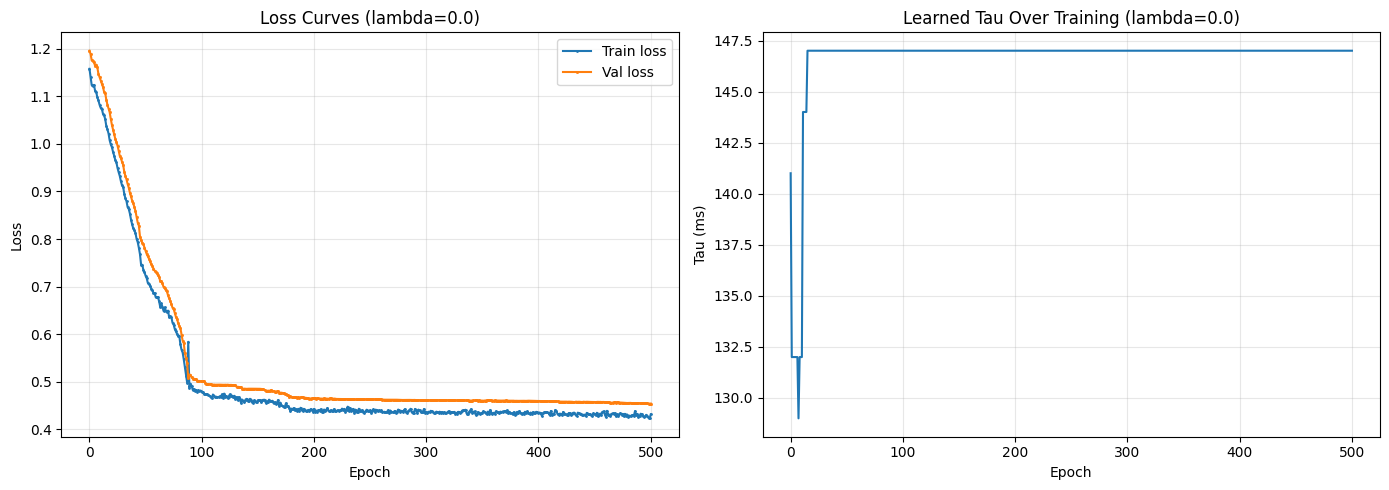

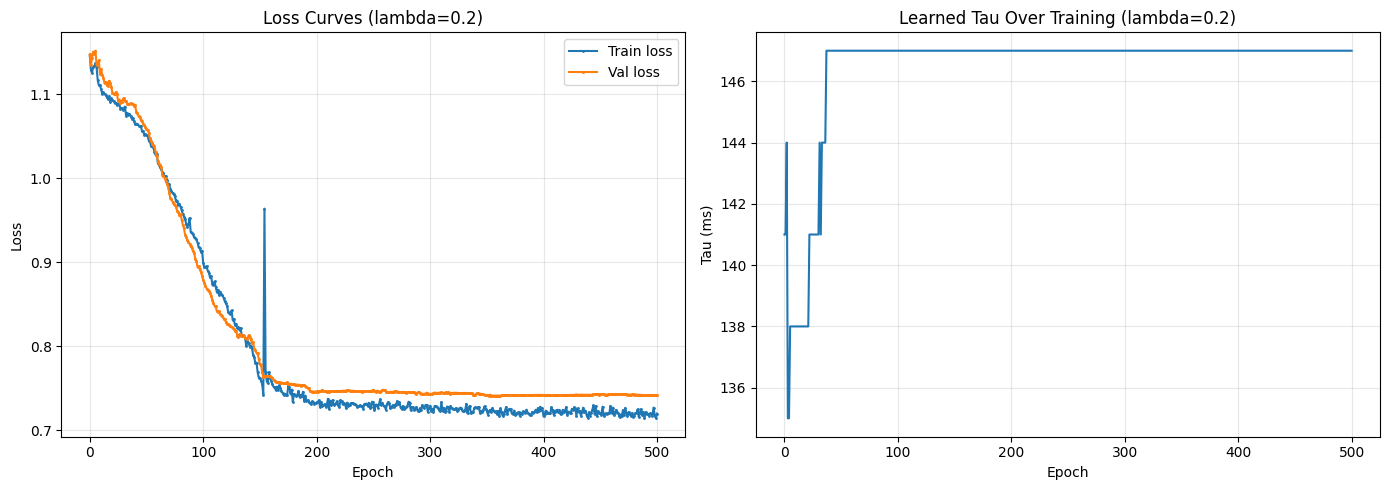

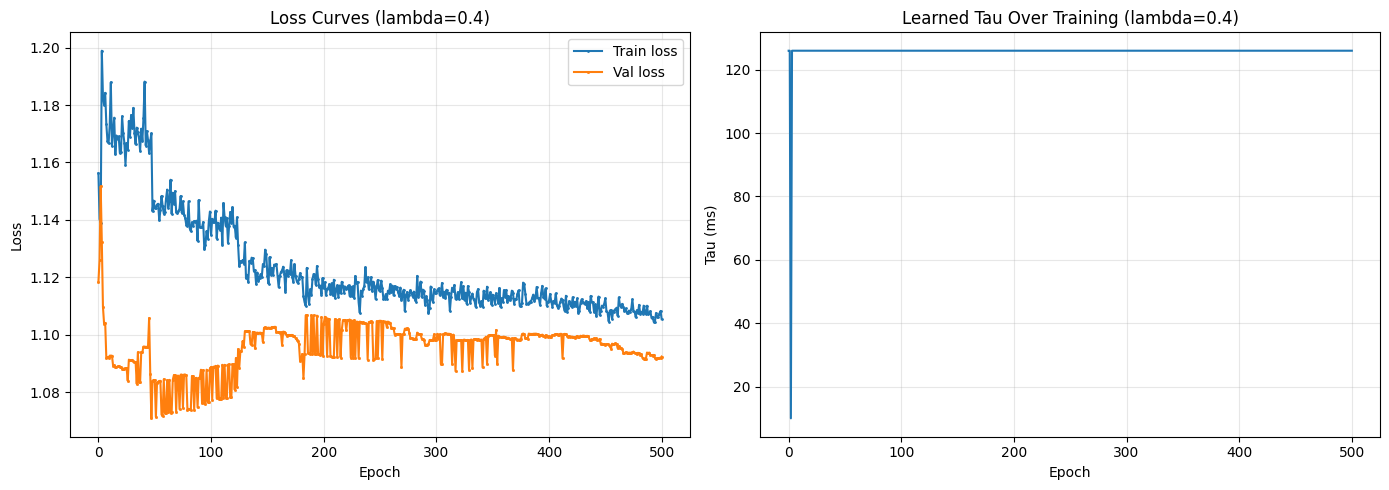

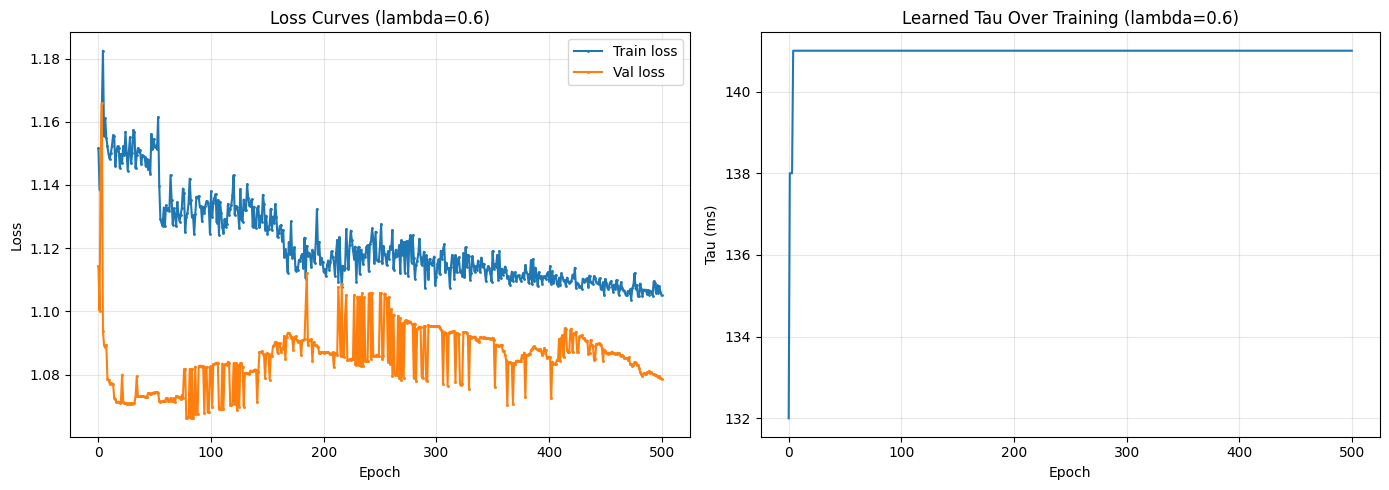

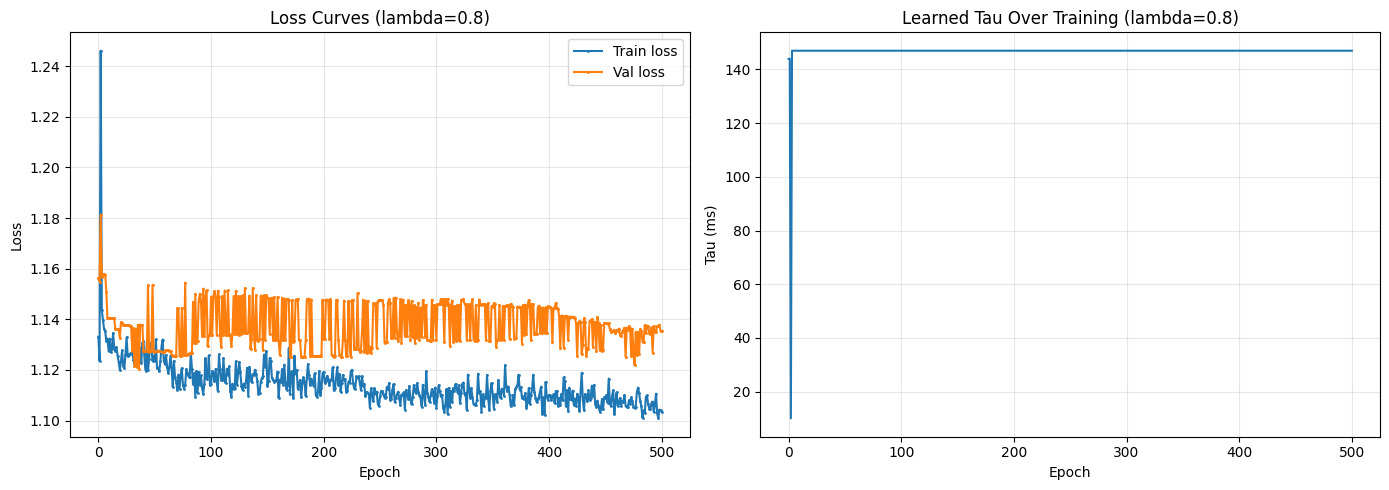

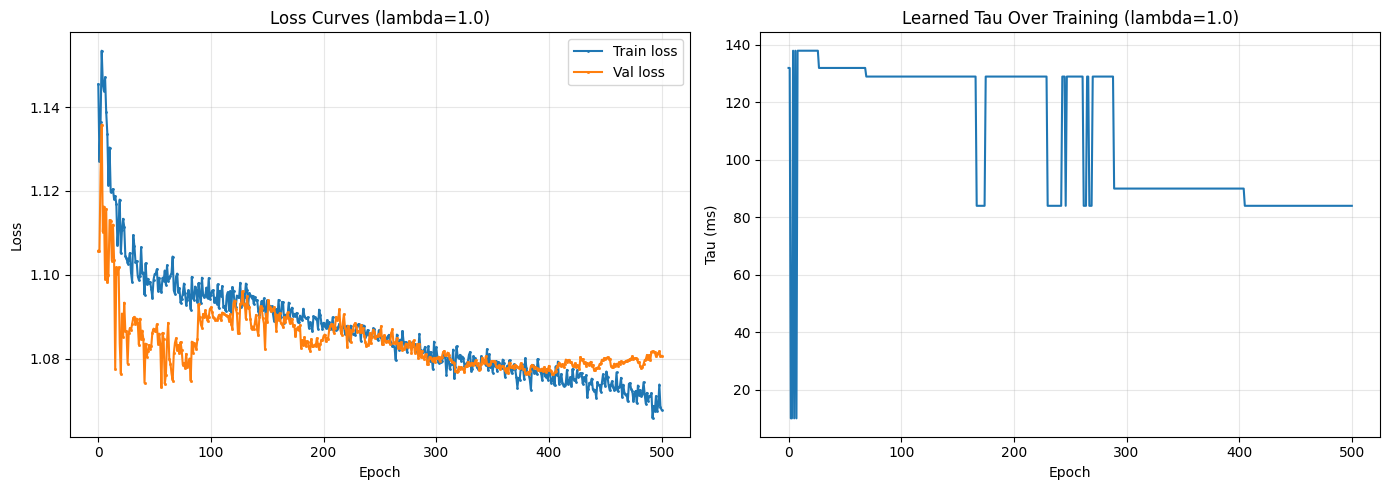

In [11]:
for lam in LAMBDA_VALUES:
    plot_training_curves(all_training_logs[lam], lam)

## 12. Plot Hidden-Perturbation Results (per Lambda)

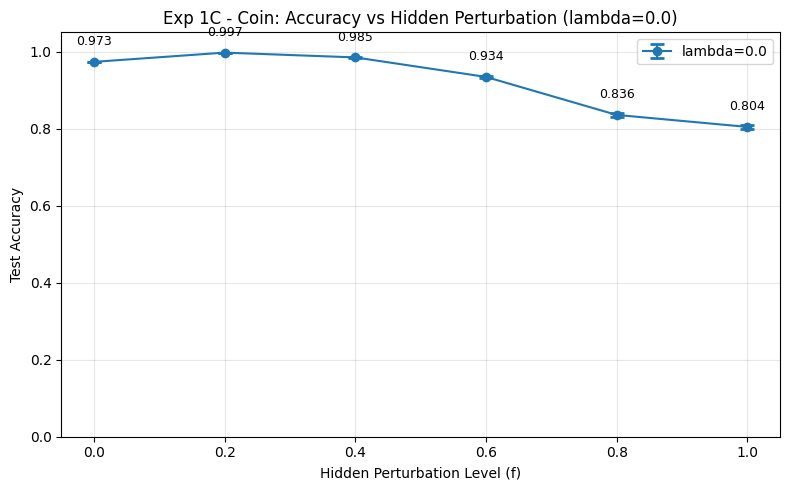

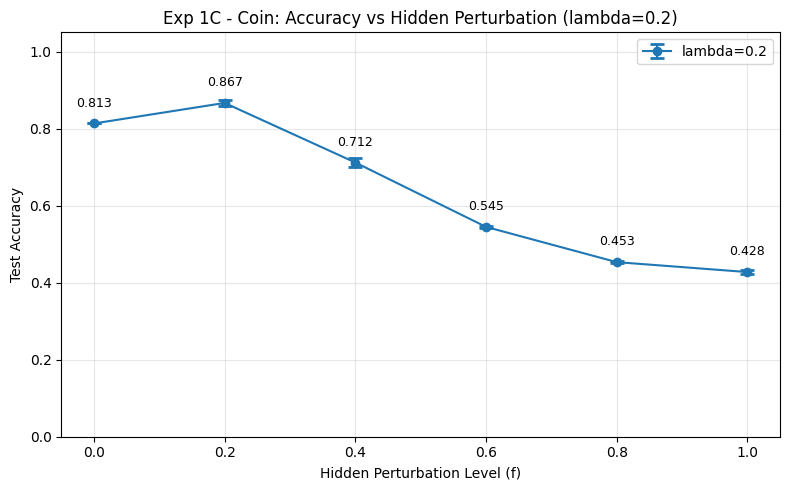

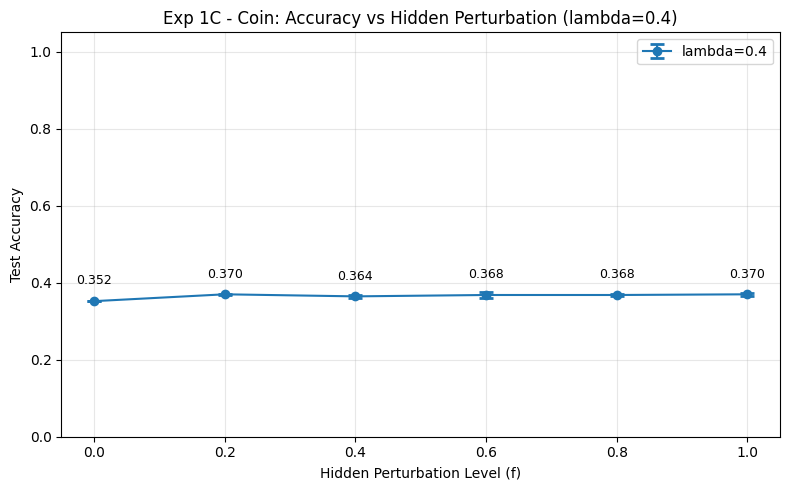

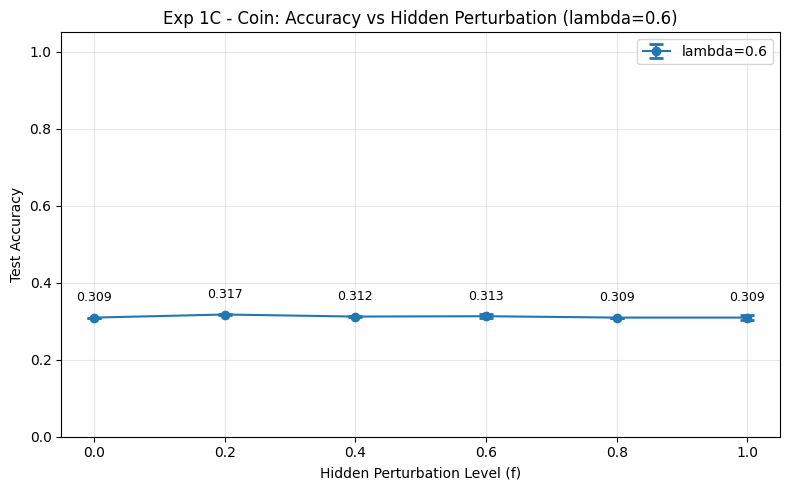

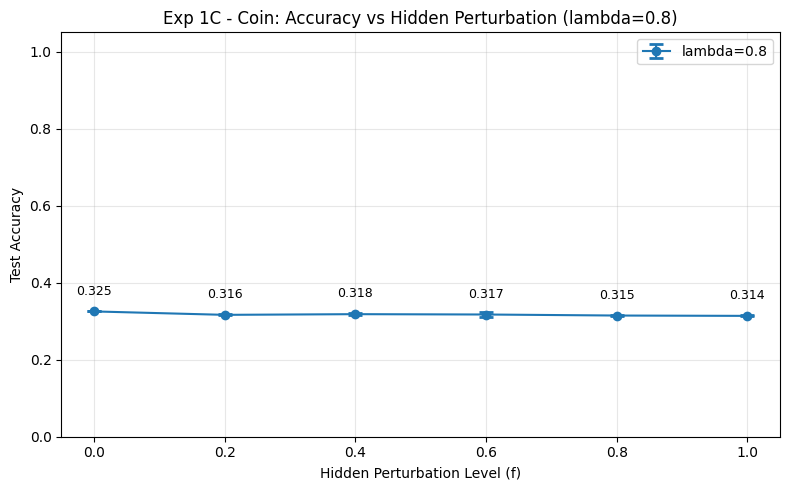

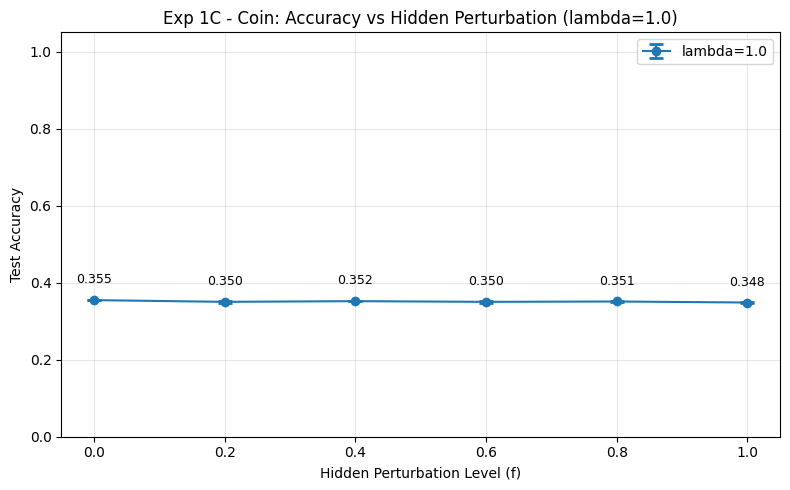

In [12]:
for lam in LAMBDA_VALUES:
    plot_hidden_perturbation_single(all_sweep_results[lam], lam)

## 13. Combined Plot: All Lambda Values

Figure saved to log/coin_tau_hidden_perturbation.png


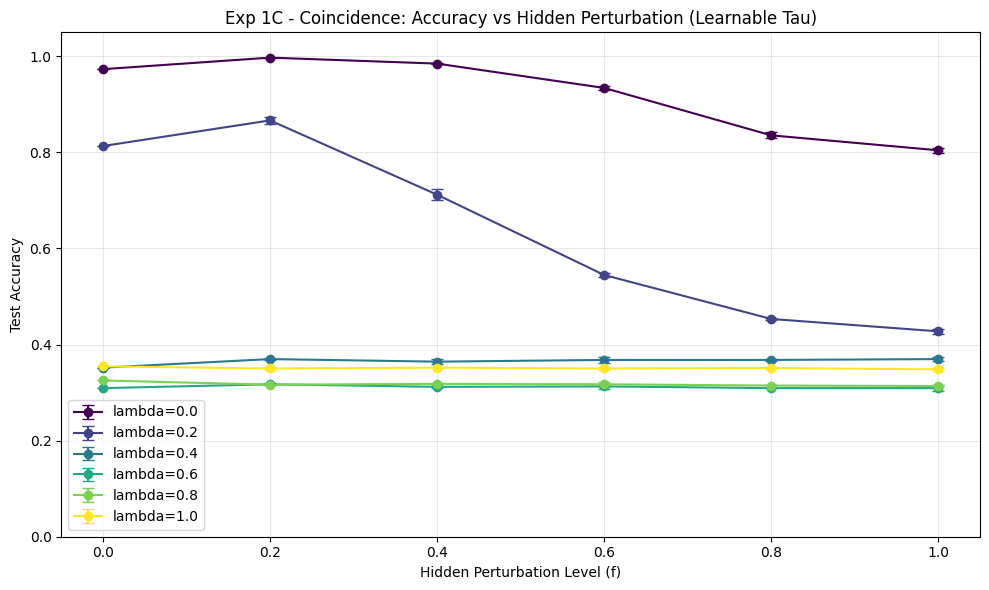

In [13]:
plot_hidden_perturbation_all_lambdas(
    all_sweep_results,
    save_path="log/coin_tau_hidden_perturbation.png",
)

## 14. Save Results

In [14]:
# --- Save perturbation sweep results ---
results_serialisable = {}
for lam, sweep in all_sweep_results.items():
    results_serialisable[str(lam)] = {
        str(f_val): {
            "mean": float(data["mean"]),
            "std": float(data["std"]),
            "values": [float(v) for v in data["values"]],
        }
        for f_val, data in sweep.items()
    }

results_path = "log/coin_tau_hidden_perturbation_results.json"
with open(results_path, "w") as fp:
    json.dump(results_serialisable, fp, indent=2)
print(f"Perturbation results saved to {results_path}")

# --- Save training logs ---
logs_serialisable = {}
for lam, log in all_training_logs.items():
    logs_serialisable[str(lam)] = {
        k: [float(v) for v in vals] if isinstance(vals, list) else vals
        for k, vals in log.items()
    }

log_path = "log/coin_tau_training_log.json"
with open(log_path, "w") as fp:
    json.dump(logs_serialisable, fp, indent=2)
print(f"Training logs saved to {log_path}")

# --- Save model summary ---
summary_path = "log/coin_tau_model_summary.json"
with open(summary_path, "w") as fp:
    json.dump(
        {str(k): v for k, v in model_info.items()},
        fp, indent=2,
    )
print(f"Model summary saved to {summary_path}")

Perturbation results saved to log/coin_tau_hidden_perturbation_results.json
Training logs saved to log/coin_tau_training_log.json
Model summary saved to log/coin_tau_model_summary.json


## 15. Model Analysis

Inspect learned tau values and weight statistics across all trained models.

In [15]:
print("=== Model Analysis Across Lambda Values ===")
print(f"{'Lambda':<10} {'Clean Acc':<12} {'Tau (ms)':<12}")
print("-" * 34)
for lam, info in model_info.items():
    print(f"{lam:<10.1f} {info['clean_accuracy']:<12.4f} {info['learned_tau_ms']:<12.2f}")

# Detailed weight analysis for the last trained model
print(f"\n--- Weight Statistics (last model, lambda={LAMBDA_VALUES[-1]}) ---")
for name, param in net.named_parameters():
    if "weight" in name:
        w = param.data
        print(f"{name}: mean={w.mean().item():.4f}, std={w.std().item():.4f}, "
              f"shape={list(w.shape)}")

# PSP filter analysis
print(f"\n--- PSP Filter ---")
filter_weights = net.psp_filter.weight.data.squeeze().cpu().numpy()
print(f"Filter max: {np.max(np.abs(filter_weights)):.4f}, "
      f"mean: {np.mean(filter_weights):.4f}")

=== Model Analysis Across Lambda Values ===
Lambda     Clean Acc    Tau (ms)    
----------------------------------
0.0        0.9733       147.00      
0.2        0.8133       147.00      
0.4        0.3520       126.00      
0.6        0.3093       141.00      
0.8        0.3253       147.00      
1.0        0.3547       132.00      

--- Weight Statistics (last model, lambda=1.0) ---
fc1.weight_g: mean=5.8475, std=0.1021, shape=[3, 1, 1, 1, 1]
fc1.weight_v: mean=-0.0503, std=0.7613, shape=[3, 60, 1, 1, 1]
fc2.weight_g: mean=3.6368, std=0.9284, shape=[3, 1, 1, 1, 1]
fc2.weight_v: mean=1.1538, std=2.0164, shape=[3, 3, 1, 1, 1]
psp_filter.weight: mean=0.1609, std=0.3208, shape=[1, 1, 1, 1, 50]

--- PSP Filter ---
Filter max: 0.8996, mean: 0.1609
